In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import random
from pathlib import Path
from ultralytics import YOLO

# Resolve paths whether the notebook is opened from the project root or notebooks/.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
best_model_path = project_root / "models" / "yolov8n_baseline_640" / "best.pt"
dataset_dir = project_root / "data" / "GTSDB" / "dataset"
output_dir = project_root / "temp" / "predictions_640"
model = YOLO(best_model_path)

def predict_image_by_id(img_id, conf=0.25):
    """
    Takes an image ID (int), opens the corresponding PPM image, and runs inference.
    """
    # Format ID to 5 digits (e.g., 45 -> 00045.ppm)
    img_name = f"{img_id:05d}.ppm"
    img_path = dataset_dir / "images" / img_name

    if not img_path.exists():
        print(f"Error: Image {img_path} not found.")
        return

    # Decode the PPM first because Ultralytics does not accept .ppm as a file suffix.
    original_rgb = Image.open(img_path).convert("RGB")
    output_dir.mkdir(parents=True, exist_ok=True)
    preview_size = (640, round(original_rgb.height * 640 / original_rgb.width))
    original_output = output_dir / f"{img_id:05d}_original_640.png"
    original_rgb.resize(preview_size, Image.Resampling.LANCZOS).save(original_output)
    results = model.predict(source=original_rgb, conf=conf, imgsz=640)

    # Show the original and annotated image together in a single figure.

    for result in results:
        # result.plot() returns a BGR numpy array with boxes/labels drawn
        res_bgr = result.plot()
        prediction_output = output_dir / f"{img_id:05d}_640.png"
        prediction_preview = cv2.resize(res_bgr, preview_size, interpolation=cv2.INTER_AREA)
        if not cv2.imwrite(str(prediction_output), prediction_preview):
            raise OSError(f"Could not save predictions: {prediction_output}")
        print(f"Saved original: {original_output}\nSaved predictions: {prediction_output}")
        res_rgb = cv2.cvtColor(res_bgr, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        axes[0].imshow(original_rgb)
        axes[0].set_title(f"Original: {img_name}")
        axes[0].axis("off")

        axes[1].imshow(res_rgb)
        axes[1].set_title(f"Predictions: {img_name}")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


def predict_random_image_by_class(class_id, conf=0.25):
    """
    Selects a random image containing class_id according to gt.txt,
    then displays the original image and the model predictions.

    Returns the selected integer image ID.
    """
    try:
        class_id = int(class_id)
    except (TypeError, ValueError) as exc:
        raise ValueError("class_id must be an integer") from exc

    gt_path = project_root / "data" / "GTSDB" / "gt.txt"
    if not gt_path.exists():
        raise FileNotFoundError(f"Ground-truth file not found: {gt_path}")

    matching_image_ids = set()
    with gt_path.open("r", encoding="utf-8") as gt_file:
        for line in gt_file:
            fields = line.strip().split(";")
            if len(fields) == 6 and int(fields[5]) == class_id:
                matching_image_ids.add(int(Path(fields[0]).stem))

    if not matching_image_ids:
        raise ValueError(f"No image in gt.txt contains class {class_id}")

    image_id = random.choice(sorted(matching_image_ids))
    print(f"Selected image {image_id:05d}.ppm for class {class_id}")
    predict_image_by_id(image_id, conf=conf)
    return image_id

In [3]:
def isolate_predictions(img_id, conf=0.25):
    """Display one image per predicted bounding box, without overlapping boxes."""
    img_name = f"{img_id:05d}.png"
    img_path = dataset_dir / "images" / img_name

    if not img_path.is_file():
        raise FileNotFoundError(f"Image not found: {img_path}")

    original = cv2.imread(str(img_path))
    if original is None:
        raise ValueError(f"Could not read image: {img_path}")

    results = model.predict(source=original, conf=conf, imgsz=640, verbose=False)
    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            print(f"No predictions for {img_name}.")
            continue

        for i, box in enumerate(result.boxes):
            image = original.copy()
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = model.names[class_id]

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 3)

            plt.figure(figsize=(14, 8))
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.title(
                f"Prediction {i}: {class_name} — "
                f"confidence {confidence:.3f} — "
                f"box ({x1}, {y1}, {x2}, {y2})"
            )
            plt.axis("off")
            plt.show()

    return results

In [4]:
analysis = model.val(
    data=dataset_dir / "data.yaml",
    split="val",       # or "test"
    imgsz=640,
    batch=8,
    device="cpu",
    plots=True,
    visualize=True,
    project="model_test_results",
    name="error_analysis_960",
    exist_ok=True,
)

Ultralytics 8.4.116 🚀 Python-3.12.3 torch-2.13.0+cpu CPU (AMD Ryzen 5 5600 6-Core Processor)
Model summary (fused): 73 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs


FileNotFoundError: [34m[1mval: [0mError loading data from /data/Programiranje/Autonomous driving/Computer Vision/Traffic Sign Detection/data/GTSDB/dataset/val.txt
See https://docs.ultralytics.com/datasets for dataset formatting guidance.


0: 384x640 1 speed limit 50, 24.2ms
Speed: 1.1ms preprocess, 24.2ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Saved original: /data/Programiranje/Autonomous driving/Computer Vision/Traffic Sign Detection/temp/predictions_640/00067_original_640.png
Saved predictions: /data/Programiranje/Autonomous driving/Computer Vision/Traffic Sign Detection/temp/predictions_640/00067_640.png


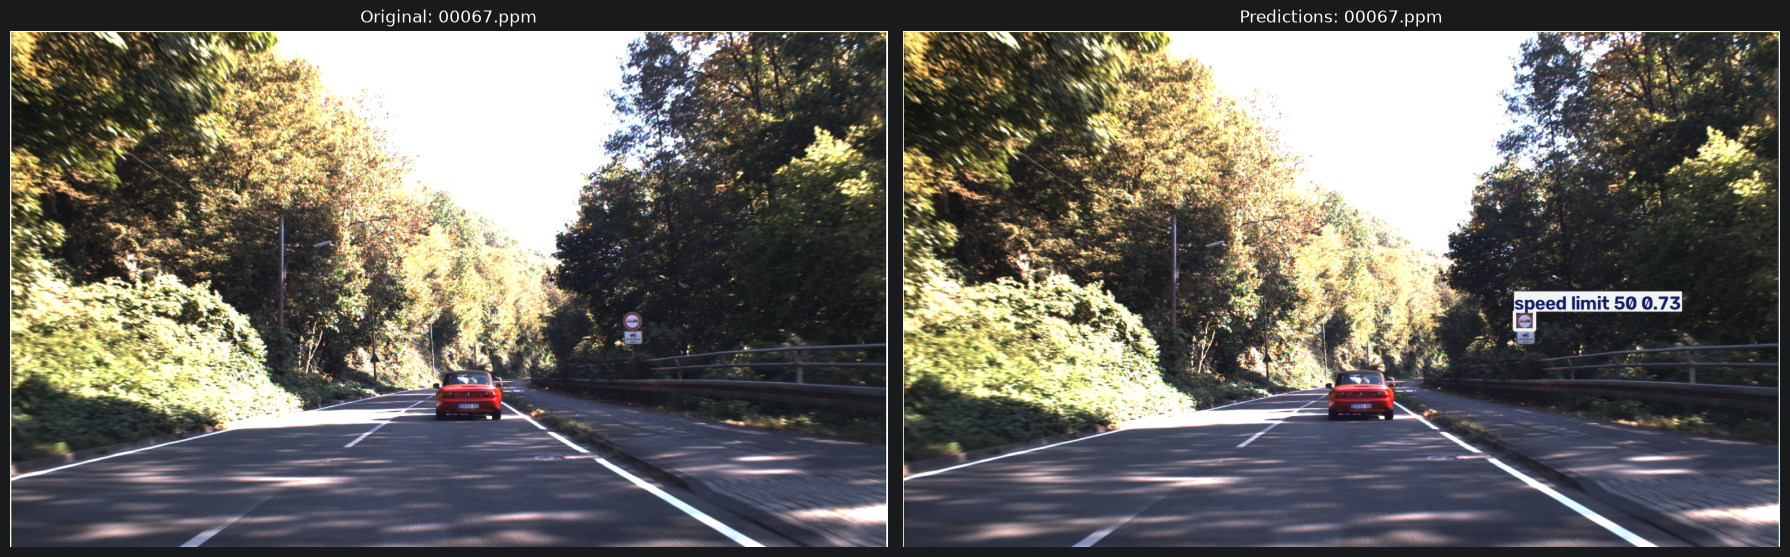

In [9]:
predict_image_by_id(67)